# Introduction

As you learned in lecture, time series data has three components: 
1. Trend
2. Seasonality
3. Residual (or Remainder)


## Learning Outcomes

What will we accomplish?

1. First, we'll separately construct each time series component. 

2. Then we'll bring the three components together to create a simulated time series dataset. 

3. Finally, we'll leverage time series model decomposition in Python to deconstruct the series. 

We'll complete this process for the two most common processes: **additive** and **multiplicative**.
The whole point of this exercise is to get you familiar with time series data and simple modeling approaches. 

You should walk away from this tutorial with:

1. A practical understanding of the three components of time series data;
 
2. A better understanding of additive and multiplicative models; and

3. A simple way to decompose time series data in Python.

## Imports 

In [1]:
%matplotlib inline

import sys
import statsmodels as ss
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

---
# Time series components

A time series is often assumed to be composed of three components:

   1. **Trend**: the long-term direction.
   2. **Seasonality**: the periodic behavior.
   3. **Residual**: the irregular fluctuations.


## Trend

- Trend captures the general direction of the time series.
- For example, increasing number of passengers over the years despite seasonal fluctuations.
- Trend can be increasing, decreasing, or constant.
- It can increase/decrease in different ways over time (linearly, exponentially, etc…).

Let's create a trend from scratch to understand how it looks like.


In [2]:
time = np.arange(1, 51)

Now we need to create a trend. Let's pretend we have a sensor measuring demand for electricity. We'll ignore units to keep things simple.

In [3]:
trend = time * 2.75

What folllows is a plot showing trend as a function of time.

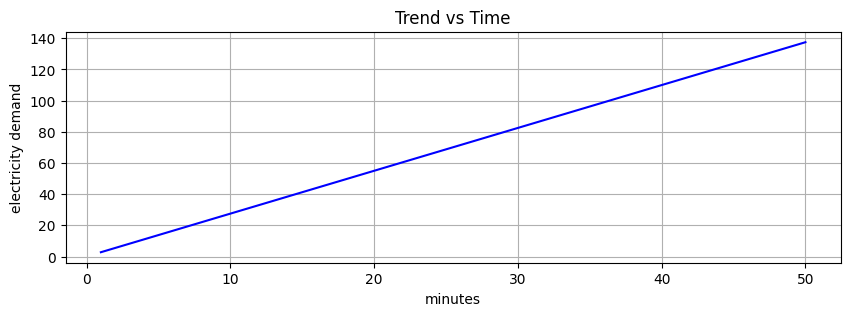

In [4]:
plt.subplots(1, 1, figsize=(10, 3))
plt.plot(time, trend, color='blue')
plt.grid()
plt.title("Trend vs Time")
plt.xlabel("minutes")
plt.ylabel("electricity demand");

## Seasonality

- Periodic fluctuations in time series data that occur at regular intervals due to seasonal factors.
- It is characterized by consistent and predictable patterns over a specific period (e.g., daily, monthly, quarterly, yearly).

It can be driven by many factors.

- Naturally occurring events such as weather fluctuations caused by time of year.
- Business or administrative procedures, such as start and end of a school year.
- Social or cultural behavior, e.g., holidays or religious observances.

Let's generate the seasonal component.

In [5]:
seasonal = 10 + np.sin(time) * 10

Naturally, we'll want to plot our seasonality.

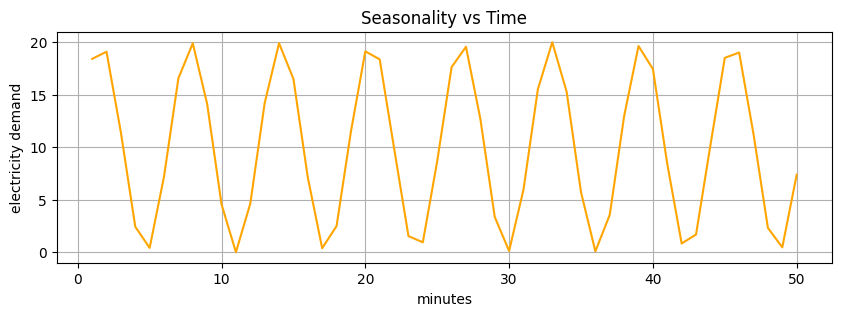

In [6]:
plt.subplots(1, 1, figsize=(10, 3))
plt.plot(time, seasonal, color='orange')
plt.grid()
plt.title("Seasonality vs Time")
plt.xlabel("minutes")
plt.ylabel("electricity demand");

## Residuals

- Residuals are the random fluctuations left over after trend and seasonality are removed from the original time series.
- One should not see a trend or seasonal pattern in the residuals.
- They represent short term, rather unpredictable fluctuations.

In [7]:
np.random.seed(10)  # reproducible results
residual = np.random.normal(loc=0.0, scale=3, size=len(time))

A quick plot of residuals...

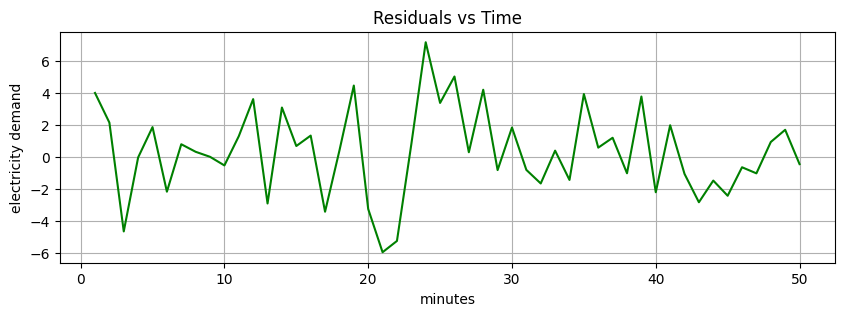

In [8]:
plt.subplots(1, 1, figsize=(10, 3))
plt.plot(time, residual, color='green')
plt.grid()
plt.title("Residuals vs Time")
plt.xlabel("minutes")
plt.ylabel("electricity demand");

Quick recap: We created data for the fictional demand of electricity as measured by a fictional sensor. We did this by creating the three necessary components of time series data, which include trend, seasonality, and residuals. 

Next step: Aggregate the three components to create time series data. We'll do this for two different types of models: additive and multiplicative.

---
# Decomposition Models

Time series components can be decomposed with the following models:
    1. Additive decomposition
    2. Multiplicative decomposition

## Additive Time Series

Additive models assume that the observed time series is the sum of its components: 
$$O_{t} = T_{t} + S_{t} + R_{t}$$ 

where
$O_{t}$ is the time series   
$T_{t}$ is the trend  
$S_{t}$ is the seasonality  
$R_{t}$ is the residual  
$_t$ is a variable representing a particular point in time 

**Tip:** Additive models are used when the magnitudes of the seasonal and residual values do not depend on the level of the trend.

In [9]:
additive = trend + seasonal + residual

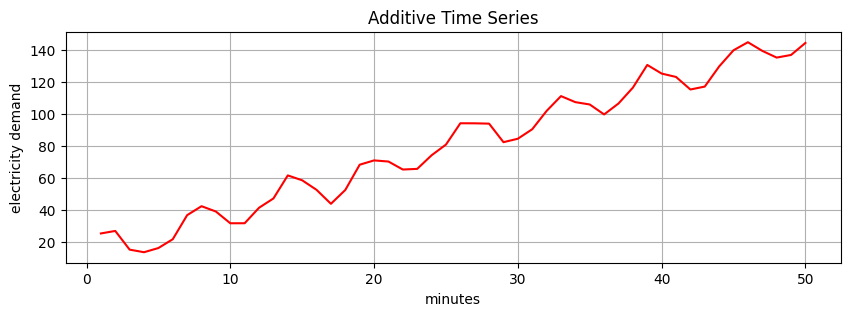

In [10]:
plt.subplots(1, 1, figsize=(10, 3))
plt.plot(time, additive, color='red')
plt.grid()
plt.title("Additive Time Series")
plt.xlabel("minutes")
plt.ylabel("electricity demand");

We clearly see trend and seasonality in the plot above, as expected.

## Multiplicative Time Series

Assumes that the observed time series is the product of its components: 
$$O_{t} = T_{t} * S_{t} * R_{t}$$ 

It is possible to transform a multiplicative model to an additive one by applying a log transformation: 

$$\log \left( T(t) \cdot S(t) \cdot R(t) \right) = \log(T(t)) + \log(S(t)) + \log(R(t))$$

**Tip:** Multiplicative models are used when the magnitudes of seasonal and residual values depends on trend. 

In [11]:
# ignoring residual to make pattern more apparent
ignored_residual = np.ones_like(residual)
multiplicative = trend * seasonal * ignored_residual

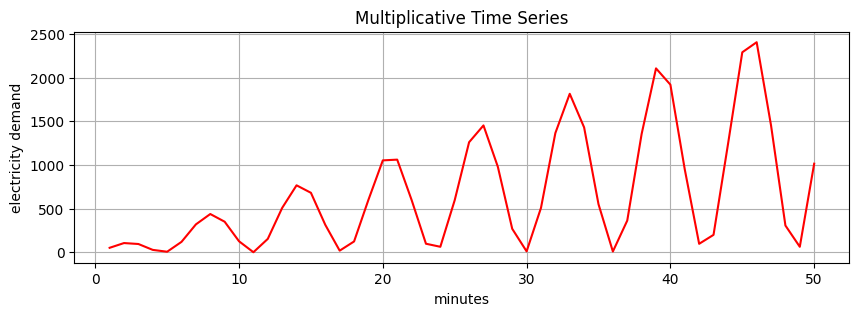

In [12]:
plt.subplots(1, 1, figsize=(10, 3))
plt.plot(time, multiplicative, color='red')
plt.grid()
plt.title("Multiplicative Time Series")
plt.xlabel("minutes")
plt.ylabel("electricity demand");

---
# Classical Time Series Decomposition

Now let's reverse directions. We have additive and multiplicative data. Let's decompose them into their three components. 

- A very simple, yet often useful, approach is to estimate a *linear* trend.
- A *detrended* time series is obtained by subtracting the linear trend from the data.
- The linear trend is computed as a 1st order polynomial.

Please note that the goal here is NOT to understand HOW the decomposition works. Rather, the goal is simply to see that the time series data that we previously constructed can be decomposed into its three constituent parts: trend, seasonality, and residual.

In [13]:
slope, intercept = np.polyfit(np.arange(len(additive)), additive, 1) # estimate line coefficient
trend = np.arange(len(additive)) * slope + intercept # linear trend
detrended = additive - trend # remove the trend

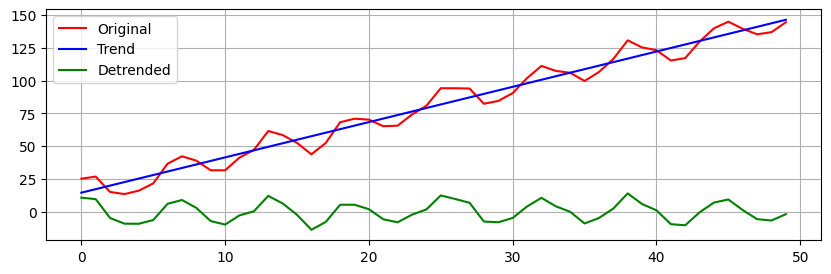

In [14]:
plt.figure(figsize=(10, 3))
plt.plot(additive, label='Original', color='red')
plt.plot(trend, label='Trend', color='blue')
plt.plot(detrended, label='Detrended', color='green')
plt.grid()
plt.legend();

- Next, we will use `seasonal_decompose` (more information [here](http://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.seasonal_decompose.html)) to isolate the main time series components.
- This is a simple method that requires us to specify the type of model (additive or multiplicative) and the main period.

## Additive Decomposition

**What this line does**

`seasonal_decompose` takes one series and splits it into trend, seasonality, and residual using a moving-average method.

- `x=additive` -- the time series to decompose (the observed data built above).
- `model='additive'` -- assume the parts add up: $O = T + S + R$. Use `'multiplicative'` when they multiply instead: $O = T * S * R$.
- `period=6` -- how many observations make up one full seasonal cycle. Our seasonal wave repeats every 6 points, so every 6th observation sits at the same place in the cycle.

How it works, in three steps:

1. **Trend** -- a centered moving average of width `period` averages the seasonal wave away, leaving the slow drift. Stored in `.trend`.
2. **Seasonality** -- subtract the trend, then average the leftovers by position within the cycle (all 1st points together, all 2nd points, and so on). That repeating profile is `.seasonal`.
3. **Residual** -- whatever is left over: $R = O - T - S$. Stored in `.resid`.

The call returns a `DecomposeResult` object, which is why the next lines pull the three components off it with `.trend`, `.seasonal`, and `.resid`.

Two gotchas: `period` must be at least 2, and the trend (and therefore the residual) is NaN for roughly the first and last `period/2` points, since the moving average has no full window there. Also note this argument used to be called `freq` -- statsmodels renamed it to `period` in version 0.11.

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

ss_decomposition = seasonal_decompose(x=additive, model='additive', period=6)
estimated_trend = ss_decomposition.trend
estimated_seasonal = ss_decomposition.seasonal
estimated_residual = ss_decomposition.resid

## Additive Decomposition Plots

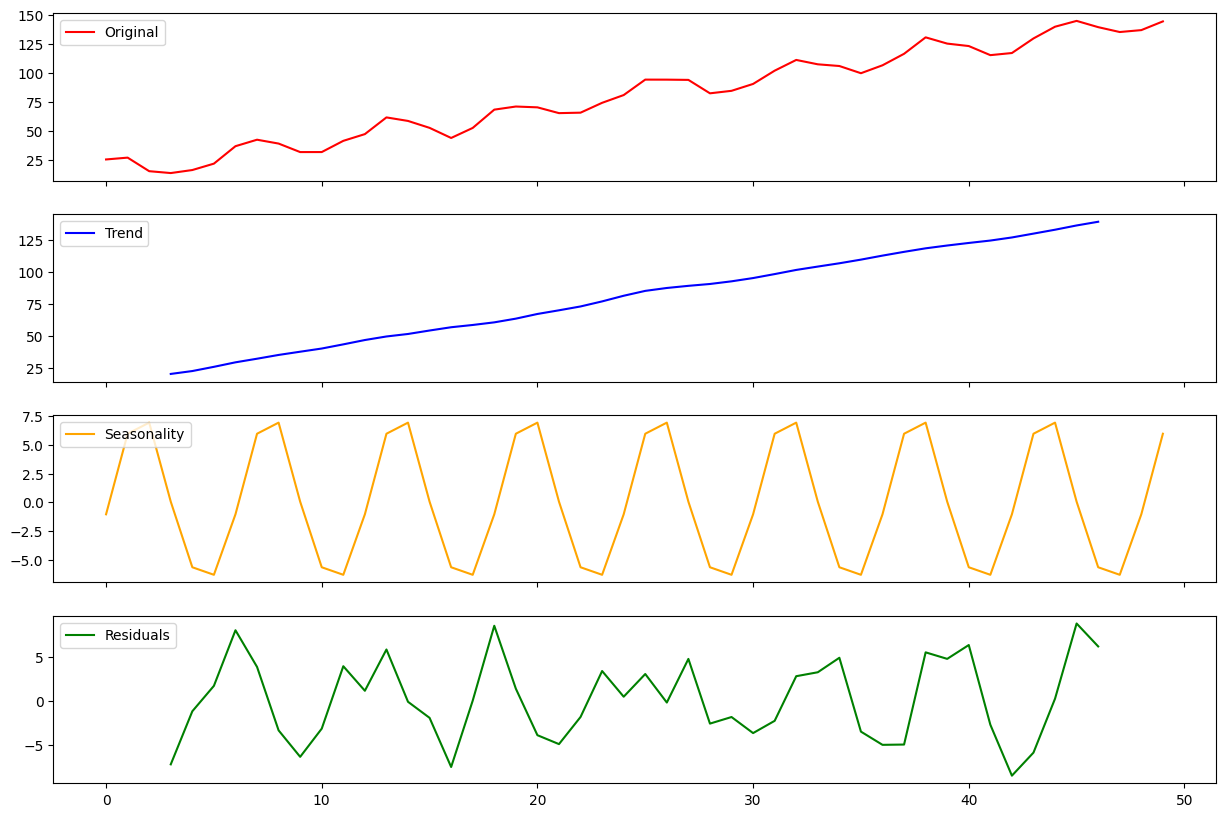

In [16]:
fig, axes = plt.subplots(4, 1, sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot(additive, label='Original', color='red')
axes[0].legend(loc='upper left');

axes[1].plot(estimated_trend, label='Trend', color='blue')
axes[1].legend(loc='upper left');

axes[2].plot(estimated_seasonal, label='Seasonality', color='orange')
axes[2].legend(loc='upper left');

axes[3].plot(estimated_residual, label='Residuals', color='green')
axes[3].legend(loc='upper left');

The line in each plot representes the decomposition. 

**NOTE:** You may notice both *trend* and *residuals* are missing data towards the beginning and end. This has to do with how trend is calculated (beyond the scope of this lesson). The residuals are missing simply because $R_{t} = O_{t} - T_{t} - S_{t}$, so missing trend values mean missing residual values as well. In other words, there is nothing wrong with these graphs. 

## Multiplicative Decomposition

- We use the same function `seasonal_decompose`, but on the `multiplicative` time series.
- Since we know this is a multiplicative time series, we declare `model='multiplicative'` in `seasonal_decompose`.


In [17]:
ss_decomposition = seasonal_decompose(x=multiplicative, model='multiplicative', period=6)
estimated_trend = ss_decomposition.trend
estimated_seasonal = ss_decomposition.seasonal
estimated_residual = ss_decomposition.resid

## Multiplicative Decomposition Plots

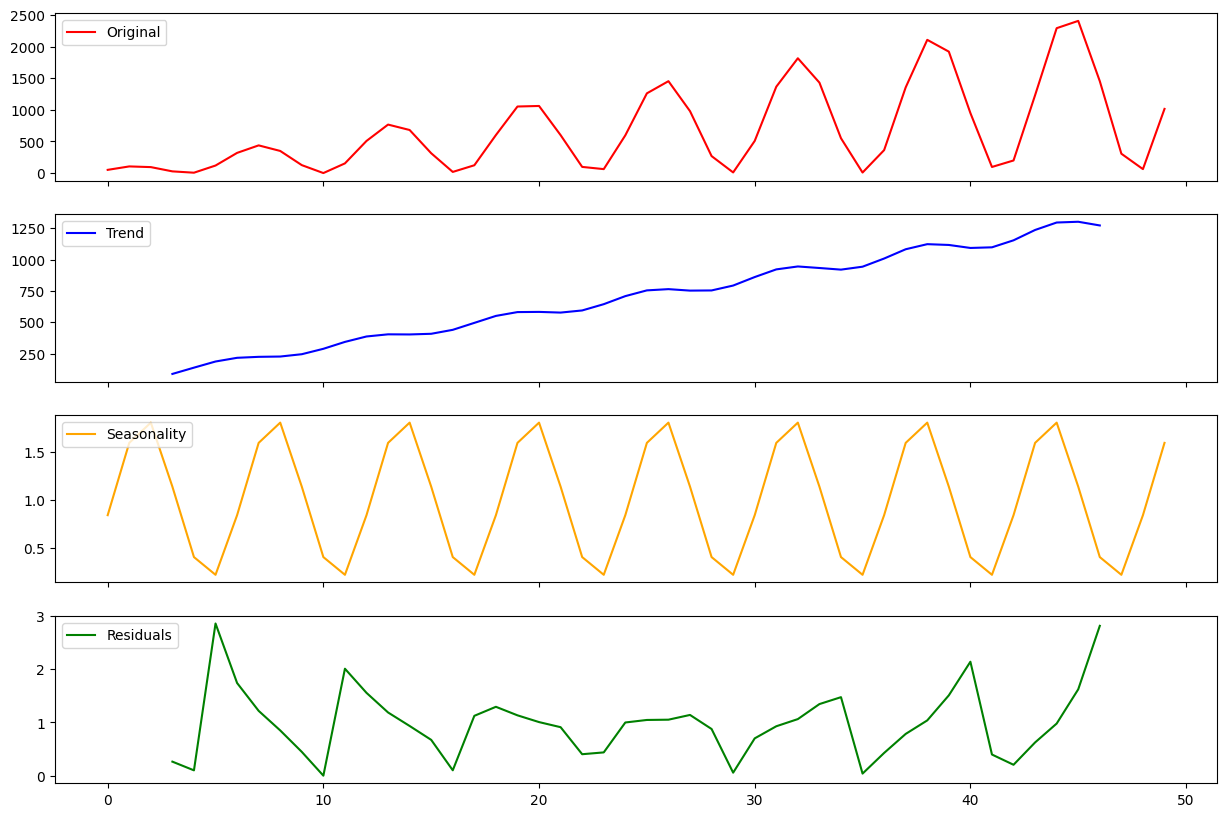

In [18]:
fig, axes = plt.subplots(4, 1, sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot(multiplicative, label='Original',color='red')
axes[0].legend(loc='upper left');

axes[1].plot(estimated_trend, label='Trend', color='blue')
axes[1].legend(loc='upper left');

axes[2].plot(estimated_seasonal, label='Seasonality', color='orange')
axes[2].legend(loc='upper left');

axes[3].plot(estimated_residual, label='Residuals', color='green')
axes[3].legend(loc='upper left');

Again, the decomposition does a relatively good job picking up the overall trend and seasonality. We can see the shapes follow the patterns we expect. 

---
# STL Decomposition

- Seasonal and Trend decomposition using LOESS (STL) is a versatile and robust method for decomposing time series. 
- LOESS is an acronym for ``locally estimated scatterplot smoothing''. 
- STL is a method for estimating nonlinear relationships.

We start with the additive model.

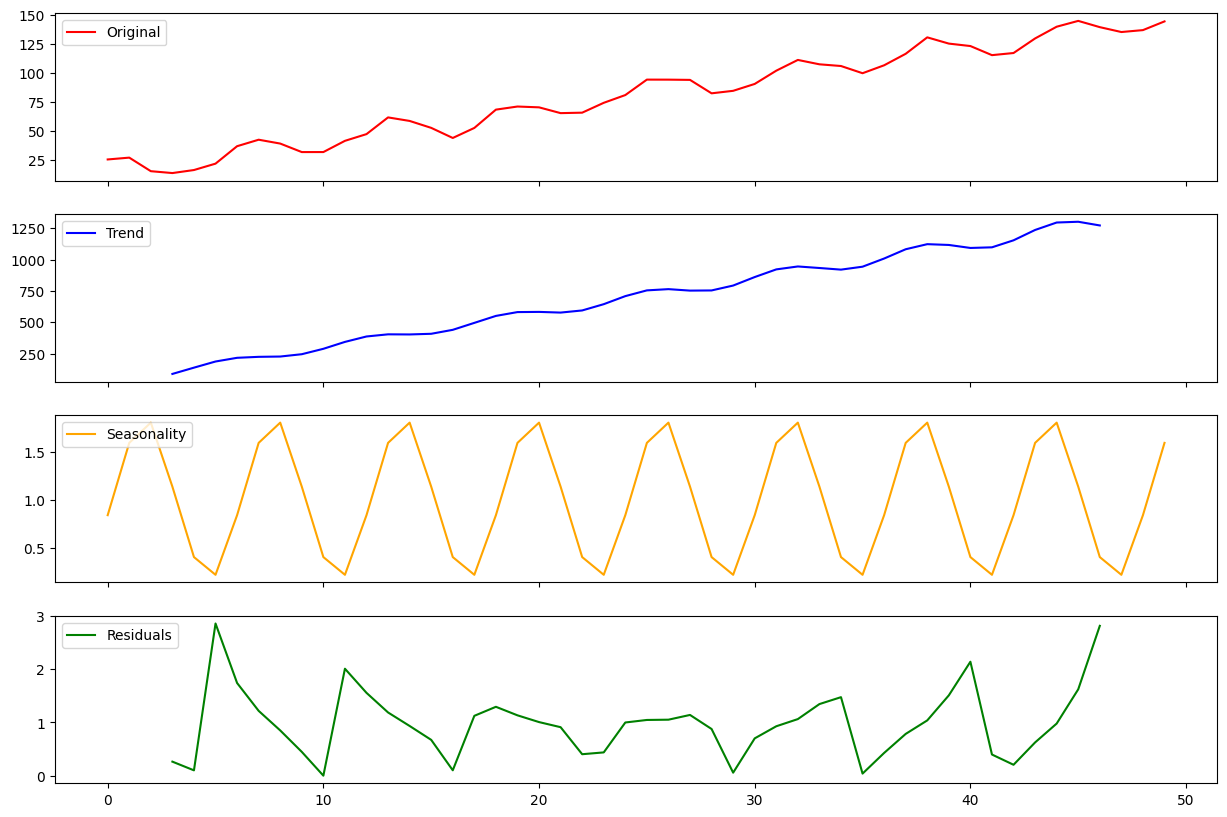

In [19]:
from statsmodels.tsa.seasonal import STL

stl_decomposition = STL(endog=additive, period=6, robust=True).fit()

fig, axes = plt.subplots(4, 1, sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot(additive, label='Original', color='red')
axes[0].legend(loc='upper left');

axes[1].plot(estimated_trend, label='Trend', color='blue')
axes[1].legend(loc='upper left');

axes[2].plot(estimated_seasonal, label='Seasonality', color='orange')
axes[2].legend(loc='upper left');

axes[3].plot(estimated_residual, label='Residuals', color='green')
axes[3].legend(loc='upper left');

- The STL decomposition does a very good job on the `additive` time series.
- Next, we try with the `multiplicative` one.

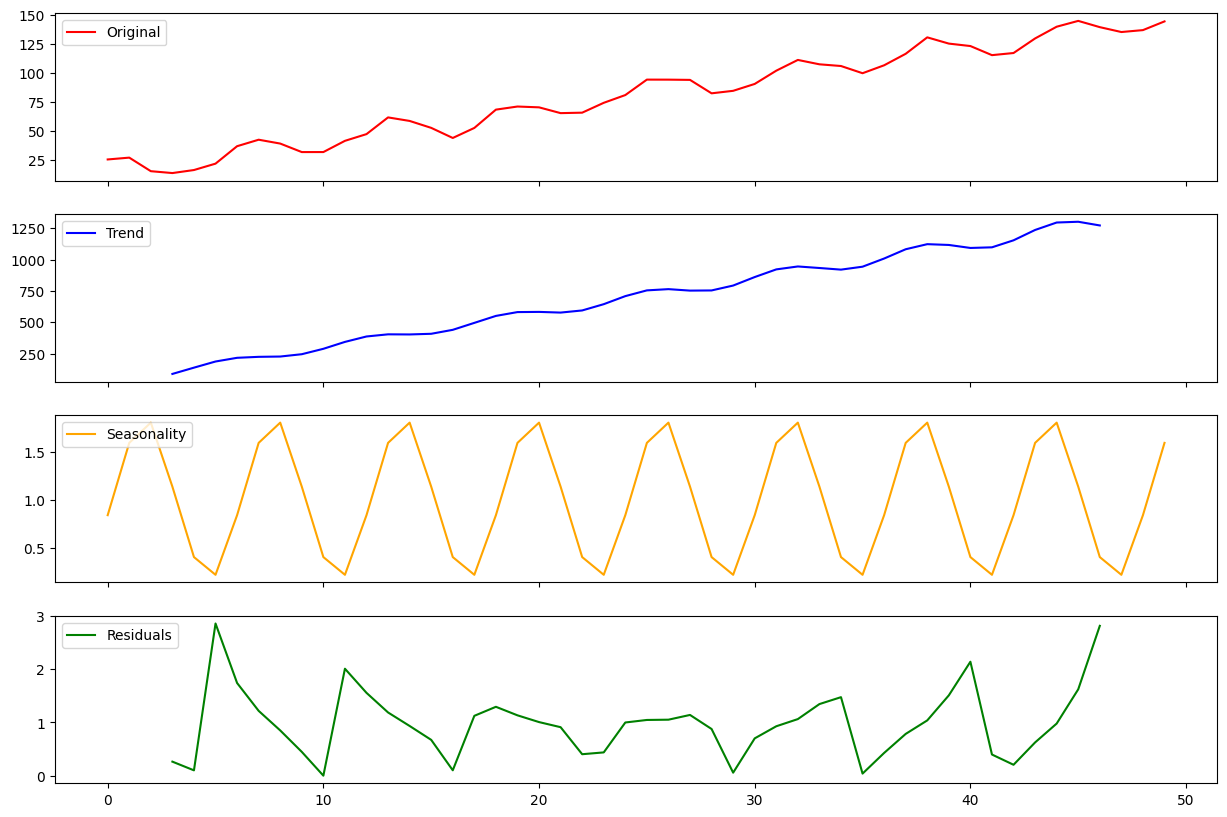

In [20]:
stl_decomposition = STL(endog=multiplicative, period=6, robust=True).fit()

fig, axes = plt.subplots(4, 1, sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot(additive, label='Original', color='red')
axes[0].legend(loc='upper left');

axes[1].plot(estimated_trend, label='Trend', color='blue')
axes[1].legend(loc='upper left');

axes[2].plot(estimated_seasonal, label='Seasonality', color='orange')
axes[2].legend(loc='upper left');

axes[3].plot(estimated_residual, label='Residuals', color='green')
axes[3].legend(loc='upper left');

**Which method to use?**

Use ``seasonal_decompose`` when:

- Your time series data has a clear and stable seasonal pattern and trend.
- You prefer a simpler model with fewer parameters to adjust.
- The seasonal amplitude is constant over time (suggesting an additive model) or varies proportionally with the trend (suggesting a multiplicative model).


Use ``STL`` when:

- Your time series exhibits complex seasonality that may change over time.
- You need to handle outliers effectively without them distorting the trend and seasonal components.
- You are dealing with non-linear trends and seasonality, and you need more control over the decomposition process.


---
# Identify Dominant Period/Frequency

- ``seasonal_decompose`` expects the dominant period as a parameter. 
- In the above examples, we said that the period was *approximately* $6$.
- But, in general, how do we find it out?


- You can use one of the following techniques:
    - Plot the data and try to figure out after how many steps the cycle repeats.
    - Do an Autocorrelation Plot (more on this later).
    - Use the Fast Fourier Transform on a signal *without* trend.
    

- We will look more into FFT later on.
- For now, you can use the following function to compute the dominant period in the data.

In [21]:
from scipy.fft import fft

def fft_analysis(signal):
    
    # Linear detrending
    slope, intercept = np.polyfit(np.arange(len(signal)), signal, 1)
    trend = np.arange(len(signal)) * slope + intercept 
    detrended = signal - trend 
    
    fft_values = fft(detrended)
    frequencies = np.fft.fftfreq(len(fft_values))

    # Remove negative frequencies and sort
    positive_frequencies = frequencies[frequencies > 0]
    magnitudes = np.abs(fft_values)[frequencies > 0]

    # Identify dominant frequency
    dominant_frequency = positive_frequencies[np.argmax(magnitudes)]
    print(f"Dominant Frequency: {dominant_frequency:.3f}")

    # Convert frequency to period (e.g., days, weeks, months, etc.)
    dominant_period = 1 / dominant_frequency
    print(f"Dominant Period: {dominant_period:.2f} time units")
    
    return dominant_period, positive_frequencies, magnitudes

In [22]:
period, freqs, magnitudes = fft_analysis(seasonal)

Dominant Frequency: 0.160
Dominant Period: 6.25 time units


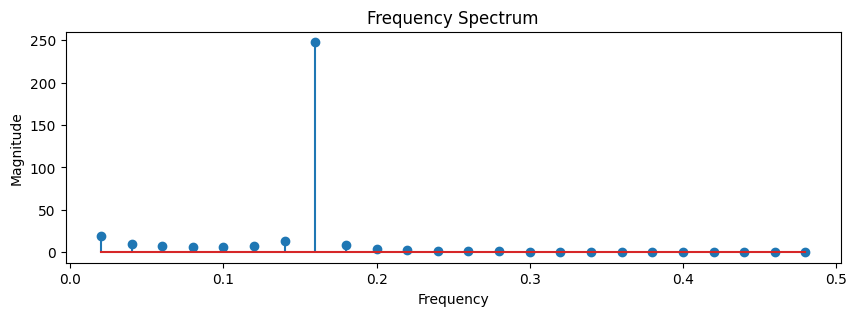

In [23]:
# Plotting the spectrum
plt.figure(figsize=(10, 3))
plt.stem(freqs, magnitudes)
plt.title('Frequency Spectrum')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.show()

---
# Summary

In this lesson, you should have gained: 
1. A practical understanding of the three components of time series data 
2. A better understanding of additive and multiplicative models
3. A simple way to decompose time series data 
